# Adam SVM — Region feature

This notebook tunes and evaluates the Adam SVM optimizer using the
`region` feature (6 one-hot columns: Atlantic, Quebec, Ontario, Prairies,
BC, Territories) instead of `Province / Territory` column (13
one-hot columns).

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from cv_tuning import (
    prepare_train_test_data_region,
    CV_FOLDS,
)
from optimizers import (
    adam_svm,
    predict_rm,
    tune_optimizer_joint_cv,
    fit_best,
    ADAM_PARAM_GRID,
    print_eval_report,
    best_per_kernel,
)

## 2. Load data — region variant

In [2]:
FILEPATH = '../data/ridings.csv'

data_region = prepare_train_test_data_region(filepath=FILEPATH)

print('Region — X_train shape:', data_region['X_train_proc'].shape)

Region — X_train shape: (273, 14)


## 3. Hyperparameter search (10-fold CV)

In [3]:
from kernels import KERNEL_REGISTRY

n_kernels = sum(len(v['param_grid']) for v in KERNEL_REGISTRY.values())
print(f'Adam param grid size : {len(ADAM_PARAM_GRID)} optimizer combos')
print(f'Kernel combos        : {n_kernels}')
print(f'Total configs        : {n_kernels * len(ADAM_PARAM_GRID)} × 10 folds')

Adam param grid size : 36 optimizer combos
Kernel combos        : 42
Total configs        : 1512 × 10 folds


In [4]:
search_region = tune_optimizer_joint_cv(
    adam_svm,
    data_region['X_train_proc'],
    data_region['y_train'],
    param_grid=ADAM_PARAM_GRID,
    verbose=True,
)

print('\nBest CV score (region):', round(search_region['best_result']['mean_cv'], 4))
print('Best config  (region):', {
    k: v for k, v in search_region['best_result'].items()
    if k not in {'mean_cv', 'std_cv', 'kernel_params'}
})

  linear    combos tested:   36  best_cv so far: 0.7802  [79s]
  rbf       combos tested:  216  best_cv so far: 0.8209  [482s]
  poly      combos tested: 1188  best_cv so far: 0.8209  [3120s]
  sigmoid   combos tested: 1512  best_cv so far: 0.8209  [3869s]

Best CV score (region): 0.8209
Best config  (region): {'kernel': 'rbf', 'lambda_reg': 0.001, 'learning_rate': 0.01, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-08, 'n_epochs': 50}


## 4. Refit on full training set with best config

In [5]:
N_EPOCHS_FINAL = 150

fit_region = fit_best(
    adam_svm,
    data_region['X_train_proc'], data_region['y_train_svm'],
    data_region['X_test_proc'],  data_region['y_test_svm'],
    best_result=search_region['best_result'],
    n_epochs_override=N_EPOCHS_FINAL,
)

y_pred_region = predict_rm(fit_region, data_region['X_test_proc'])
acc_region    = accuracy_score(data_region['y_test'], y_pred_region)

print(f'Test accuracy — Region : {acc_region:.4f}')

Test accuracy — Region : 0.8841


## 5. Classification report

In [6]:
print_eval_report(data_region['y_test'], y_pred_region,
                  model_name='Adam SVM — Region')

=== Adam SVM — Region ===
Test Accuracy : 0.8841

  Std    : 0.3202
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        35
           1       0.88      0.88      0.88        34

    accuracy                           0.88        69
   macro avg       0.88      0.88      0.88        69
weighted avg       0.88      0.88      0.88        69

--- Confusion Matrix ---
[[31  4]
 [ 4 30]]



## 6. Summary table

In [7]:
summary = pd.DataFrame({
    'Model':           ['Region'],
    'Input features':  [data_region['X_train_proc'].shape[1]],
    'Best CV score':   [round(search_region['best_result']['mean_cv'], 4)],
    'Test accuracy':   [round(acc_region, 4)],
    'Search time (s)': [round(search_region['fit_time_s'], 1)],
})

summary

,Model,Input features,Best CV score,Test accuracy,Search time (s)
0,Region,14,0.8209,0.8841,3868.5


## 7. Kernel performance comparison

For each kernel, the bar shows the **best mean CV accuracy** (across all
Adam hyperparameter combos) ± 1 std.

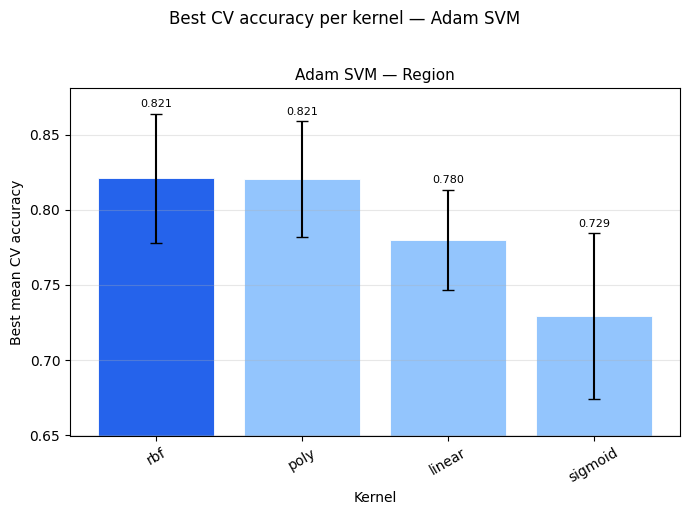

In [8]:
bpk_region = best_per_kernel(search_region['results_df'])

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#2563eb' if i == 0 else '#93c5fd' for i in range(len(bpk_region))]
bars = ax.bar(bpk_region['kernel'], bpk_region['mean_cv'],
              yerr=bpk_region['std_cv'], capsize=4,
              color=colors, edgecolor='white', linewidth=0.6)
ax.set_title('Adam SVM — Region', fontsize=11)
ax.set_xlabel('Kernel')
ax.set_ylabel('Best mean CV accuracy')
ax.set_ylim(
    max(0, bpk_region['mean_cv'].min() - 0.08),
    min(1, bpk_region['mean_cv'].max() + 0.06),
)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar, val, std in zip(bars, bpk_region['mean_cv'], bpk_region['std_cv']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.003,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=8,
    )

plt.suptitle('Best CV accuracy per kernel — Adam SVM', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Learning curve

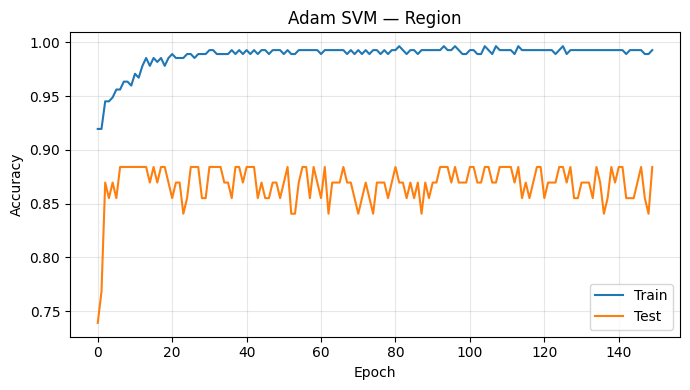

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(fit_region['train_acc_history'], label='Train')
ax.plot(fit_region['test_acc_history'],  label='Test')
ax.set_title('Adam SVM — Region')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()